In [1]:
import os
import pandas as pd
import numpy as np
from tqdm import tqdm
import boto3
import pickle
from pprint import pprint
import sklearn.metrics as skm
import matplotlib.pyplot as plt
import warnings
# Suppress PerformanceWarning
warnings.filterwarnings('ignore')
try:
    import catboost as cb
except:
    ! pip install catboost
    import catboost as cb

### Functions

In [2]:
# download from s3
def download_from_s3(str_local_path, str_bucket_path, str_project):
    # init client
    cls_client = boto3.client(
        's3',
    )
    # download file
    cls_client.download_file(
        str_project, 
        str_bucket_path, 
        str_local_path,
    )

### Constants

In [3]:
str_dirname_output = './output'

str_variant = 'noPTImodel10'

# get the time
str_time = os.getcwd().split('/')[-1]
str_target = f'Early_Pay_Delinquency_{str_time}_Flag'
print(f'Target: {str_target}')

Target: Early_Pay_Delinquency_30_180_Flag


### Output directory

In [4]:
try:
    os.mkdir(str_dirname_output)
except:
    pass

### Get the features in the model

In [5]:
str_filename = 'final_model.pkl'
str_bucket_path = f'02_pricing_pd/02_model/{str_variant}/03_final_model/{str_filename}'
str_local_path = f'./{str_filename}'
download_from_s3(
    str_local_path=str_local_path, 
    str_bucket_path=str_bucket_path, 
    str_project='20231010-gen-xii',
)
# import
cls_model_inference = pickle.load(open(str_local_path, 'rb'))['model_inference']
# rm
os.remove(str_local_path)
# get features
list_cols_model = list(cls_model_inference.feature_names_)
print(f'There are {len(list_cols_model)} columns in the model')

There are 122 columns in the model


### Load data

In [6]:
str_filename = 'df.gzip'
str_uri = f's3://20231010-gen-xii/14_monitoring/05_get_data/{str_filename}'
df = pd.read_parquet(str_uri)
df

,bigAccountId,data_set,fltgrossmonthly__income_sum,intopenbktype__app,bankruptcystatus__ln,bankruptcycount24month__ln,strname__app,strdealershiptrackertype__app,g990s__tu,bankruptcytimenewest__ln,...,agg903__tu,ret205__tu,at25s__tu,rev315__tu,g206b__tu,st25s__tu,businessassociationtimeoldest__ln,g218d__tu,ENG-loan_to_value,fltapproveddowntotal__app
38325,1337511,train,5000.0,nan,0.0,0.0,ohio,franchise,7.0,-1.0,...,0.0,-1.00,1.0,-1.0,0.000000,-1.0,-1.0,-1.0,1.370370,2500.0
38324,1337511,train,5000.0,nan,0.0,0.0,ohio,franchise,7.0,-1.0,...,0.0,-1.00,1.0,-1.0,0.000000,-1.0,-1.0,-1.0,1.370370,2500.0
38326,1337528,train,2000.0,7.0,1.0,1.0,tennessee,independent,2.0,4.0,...,1.0,8.02,1.0,7.0,0.000000,-1.0,-1.0,-1.0,1.586207,0.0
38327,1337528,train,2000.0,7.0,1.0,1.0,tennessee,independent,2.0,4.0,...,1.0,8.02,1.0,7.0,0.000000,-1.0,-1.0,-1.0,1.586207,0.0
38329,1337539,train,11000.0,nan,0.0,0.0,texas,independent,0.0,-1.0,...,0.0,-1.00,2.0,13.0,561.549063,1.0,-1.0,2.0,1.342857,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7864,4812498,test,5500.0,nan,0.0,0.0,georgia,franchise,-4.0,-1.0,...,0.0,-2.00,3.0,-1.0,374.322569,0.0,-1.0,-1.0,1.548387,0.0
7863,4812498,test,5500.0,nan,0.0,0.0,georgia,franchise,-4.0,-1.0,...,0.0,-2.00,3.0,-1.0,374.322569,0.0,-1.0,-1.0,1.548387,0.0
20360,4812503,test,4500.0,7.0,1.0,0.0,alabama,franchise,5.0,75.0,...,2.0,-1.00,4.0,2.0,0.000000,1.0,-1.0,0.0,1.044444,3500.0
20361,4812503,test,4500.0,7.0,1.0,0.0,alabama,franchise,5.0,75.0,...,2.0,-1.00,4.0,2.0,0.000000,1.0,-1.0,0.0,1.044444,3500.0


### Get the target

In [7]:
# get the early indicator targets
list_cols = ['bigAccountId', str_target]
str_filename = 'df_targets.gzip'
str_uri = f's3://20240327-genxii-v2/02_target_creation/01_classification/{str_filename}'
df_tmp = pd.read_parquet(str_uri, columns=list_cols)
df_tmp

,bigAccountId,Early_Pay_Delinquency_30_180_Flag
0,6,0
1,25,0
2,73,0
3,82,1
4,122,0
...,...,...
331103,7897024,0
331104,7897157,0
331105,7897219,0
331106,7898715,0


### Join

In [8]:
df = pd.merge(
    left=df,
    right=df_tmp,
    on='bigAccountId',
    how='left',
)
# rename
dict_rename = {
    str_target: 'target',
}
df.rename(columns=dict_rename, inplace=True)
# show
df

,bigAccountId,data_set,fltgrossmonthly__income_sum,intopenbktype__app,bankruptcystatus__ln,bankruptcycount24month__ln,strname__app,strdealershiptrackertype__app,g990s__tu,bankruptcytimenewest__ln,...,ret205__tu,at25s__tu,rev315__tu,g206b__tu,st25s__tu,businessassociationtimeoldest__ln,g218d__tu,ENG-loan_to_value,fltapproveddowntotal__app,target
0,1337511,train,5000.0,nan,0.0,0.0,ohio,franchise,7.0,-1.0,...,-1.00,1.0,-1.0,0.000000,-1.0,-1.0,-1.0,1.370370,2500.0,0
1,1337511,train,5000.0,nan,0.0,0.0,ohio,franchise,7.0,-1.0,...,-1.00,1.0,-1.0,0.000000,-1.0,-1.0,-1.0,1.370370,2500.0,0
2,1337528,train,2000.0,7.0,1.0,1.0,tennessee,independent,2.0,4.0,...,8.02,1.0,7.0,0.000000,-1.0,-1.0,-1.0,1.586207,0.0,0
3,1337528,train,2000.0,7.0,1.0,1.0,tennessee,independent,2.0,4.0,...,8.02,1.0,7.0,0.000000,-1.0,-1.0,-1.0,1.586207,0.0,0
4,1337539,train,11000.0,nan,0.0,0.0,texas,independent,0.0,-1.0,...,-1.00,2.0,13.0,561.549063,1.0,-1.0,2.0,1.342857,0.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
186170,4812498,test,5500.0,nan,0.0,0.0,georgia,franchise,-4.0,-1.0,...,-2.00,3.0,-1.0,374.322569,0.0,-1.0,-1.0,1.548387,0.0,0
186171,4812498,test,5500.0,nan,0.0,0.0,georgia,franchise,-4.0,-1.0,...,-2.00,3.0,-1.0,374.322569,0.0,-1.0,-1.0,1.548387,0.0,0
186172,4812503,test,4500.0,7.0,1.0,0.0,alabama,franchise,5.0,75.0,...,-1.00,4.0,2.0,0.000000,1.0,-1.0,0.0,1.044444,3500.0,1
186173,4812503,test,4500.0,7.0,1.0,0.0,alabama,franchise,5.0,75.0,...,-1.00,4.0,2.0,0.000000,1.0,-1.0,0.0,1.044444,3500.0,1


### Get non-numeric features

In [9]:
list_cols_non_numeric = []
for col in list_cols_model:
    if df[col].dtype not in ['float64','int64']:
        list_cols_non_numeric.append(col)
print(f'There are {len(list_cols_non_numeric)} non-numeric features:')
for a, col in enumerate(list_cols_non_numeric):
    print(f'{a+1} - {col}')

There are 6 non-numeric features:
1 - intopenbktype__app
2 - strname__app
3 - strdealershiptrackertype__app
4 - dealerstate__app
5 - vehiclemake__app
6 - addrcurrentdwelltype__ln


### Pool training data

In [10]:
df_train = df[df['data_set'] == 'train'].copy()
flt_mean_train = df_train['target'].mean()
print(f'Mean of Target in Train: {flt_mean_train}')
# pool
pool_train = cb.Pool(
    df_train[list_cols_model], 
    df_train['target'], 
    cat_features=list_cols_non_numeric,
)

Mean of Target in Train: 0.08330871491875923


### Pool validation data

In [11]:
df_valid = df[df['data_set'] == 'valid'].copy()
flt_mean_valid = df_valid['target'].mean()
print(f'Mean of Target in Valid: {flt_mean_valid}')
# pool
pool_valid = cb.Pool(
    df_valid[list_cols_model], 
    df_valid['target'], 
    cat_features=list_cols_non_numeric,
)

Mean of Target in Valid: 0.08612864240633812


### Get hyperparameters

In [12]:
str_filename = 'df.csv'
str_local_path = f'../../06_tuning/{str_time}/output/{str_filename}'
df_tmp = pd.read_csv(str_local_path)

# get the eval metric
str_eval_metric = df_tmp['eval_metric'].iloc[0]
print(f'Eval metric: {str_eval_metric}')

# logic
if str_eval_metric == 'Logloss':
    bool_ascending = True
elif str_eval_metric == 'AUC':
    bool_ascending = False
# sort
df_tmp.sort_values(by='valid_score', ascending=bool_ascending, inplace=True)

# iterations
int_n_iterations = df_tmp['iterations'].iloc[0]
print(f'Iterations: {int_n_iterations}')

# early stopping
flt_prop_early_stopping = df_tmp['prop_early_stopping'].iloc[0]
print(f'Proportion Early Stopping: {flt_prop_early_stopping}')

# get lr
flt_lr = df_tmp['learning_rate'].iloc[0]
print(f'Best Learning Rate: {flt_lr}')

# class weights
list_class_weights = eval(df_tmp['class_weights'].iloc[0])
print(f'Class weights: {list_class_weights}')

# monotone constraints
dict_monotone_constraints = eval(df_tmp['monotone_constraints'].iloc[0])
print(f'Monotone Constraints: {dict_monotone_constraints}')

# get valid score
flt_valid_score = df_tmp['valid_score'].iloc[0]
print(f'Validation {str_eval_metric}: {flt_valid_score}')

# show
#df_tmp

Eval metric: Logloss
Iterations: 1000
Proportion Early Stopping: 0.05
Best Learning Rate: 0.1724
Class weights: [0.7582408978545808, 3.6602074253802686]
Monotone Constraints: {'fltgrossmonthly__income_sum': -1, 'fltapproveddowntotal__app': -1, 'fltdowncash__app': -1, 'ENG-loan_to_value': 1, 'ENG-vehicle_age': 1, 'fltadvance__app': 1}
Validation Logloss: 0.3740139124337539


### Plot it

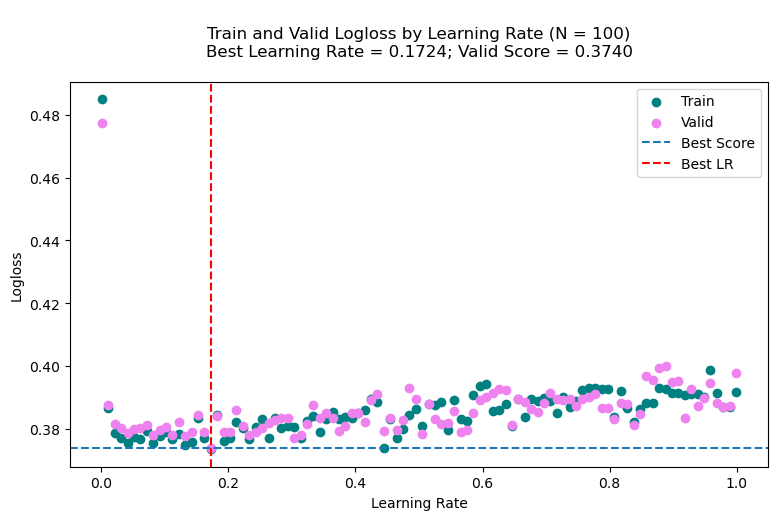

In [13]:
x = df_tmp['learning_rate']
y = df_tmp['train_score']
z = df_tmp['valid_score']
int_n_jobs = df_tmp.shape[0]
str_title = f"""
Train and Valid {str_eval_metric} by Learning Rate (N = {int_n_jobs})
Best Learning Rate = {flt_lr}; Valid Score = {flt_valid_score:0.4f}
"""
fig, ax = plt.subplots(figsize=(9,5))
# title
ax.set_title(str_title)
# x
ax.set_xlabel('Learning Rate')
# y
ax.set_ylabel(str_eval_metric)
# train
ax.scatter(x, y, label='Train', color='teal')
# valid
ax.scatter(x, z, label='Valid', color='violet')
# horizontal line for best score
ax.axhline(flt_valid_score, label='Best Score', linestyle='--')
# vertical line for best LR
ax.axvline(flt_lr, label='Best LR', color='red', linestyle='--')
# legend
plt.legend()
# show
plt.show()

### Get test data

In [14]:
df_test = df[df['data_set'] == 'test'].copy()
flt_mean_test = df_test['target'].mean()
print(f'Mean of Target in Test: {flt_mean_test}')
# show
df_test

Mean of Target in Test: 0.11787296898079763


,bigAccountId,data_set,fltgrossmonthly__income_sum,intopenbktype__app,bankruptcystatus__ln,bankruptcycount24month__ln,strname__app,strdealershiptrackertype__app,g990s__tu,bankruptcytimenewest__ln,...,ret205__tu,at25s__tu,rev315__tu,g206b__tu,st25s__tu,businessassociationtimeoldest__ln,g218d__tu,ENG-loan_to_value,fltapproveddowntotal__app,target
148940,3932700,test,5500.0,nan,0.0,0.0,ohio,franchise,-4.0,-1.0,...,-1.00,-3.0,-1.0,0.000000,-1.0,-1.0,-1.0,1.282051,500.0,0
148941,3932720,test,8000.0,nan,0.0,0.0,tennessee,franchise,4.0,-1.0,...,1.95,1.0,1.0,544.269515,-3.0,-1.0,-1.0,1.322581,2500.0,0
148942,3932720,test,8000.0,nan,0.0,0.0,tennessee,franchise,4.0,-1.0,...,1.95,1.0,1.0,544.269515,-3.0,-1.0,-1.0,1.322581,2500.0,0
148943,3932724,test,3000.0,nan,0.0,0.0,ohio,franchise,2.0,-1.0,...,-1.00,-6.0,2.0,0.000000,-3.0,-1.0,0.0,1.195652,0.0,0
148944,3932724,test,3000.0,nan,0.0,0.0,ohio,franchise,2.0,-1.0,...,-1.00,-6.0,2.0,0.000000,-3.0,-1.0,0.0,1.195652,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
186170,4812498,test,5500.0,nan,0.0,0.0,georgia,franchise,-4.0,-1.0,...,-2.00,3.0,-1.0,374.322569,0.0,-1.0,-1.0,1.548387,0.0,0
186171,4812498,test,5500.0,nan,0.0,0.0,georgia,franchise,-4.0,-1.0,...,-2.00,3.0,-1.0,374.322569,0.0,-1.0,-1.0,1.548387,0.0,0
186172,4812503,test,4500.0,7.0,1.0,0.0,alabama,franchise,5.0,75.0,...,-1.00,4.0,2.0,0.000000,1.0,-1.0,0.0,1.044444,3500.0,1
186173,4812503,test,4500.0,7.0,1.0,0.0,alabama,franchise,5.0,75.0,...,-1.00,4.0,2.0,0.000000,1.0,-1.0,0.0,1.044444,3500.0,1


### Save memory

In [15]:
del df

### Initialize model

In [16]:
# init class
cls_model_inference = cb.CatBoostClassifier(
    task_type='CPU',
    nan_mode='Min',
    random_state=42,
    eval_metric=str_eval_metric,
    iterations=int_n_iterations,
    learning_rate=flt_lr,
    class_weights=list_class_weights,
    monotone_constraints=dict_monotone_constraints,
)

### Fit model

In [17]:
# fit model
cls_model_inference.fit(
    pool_train,
    eval_set=[pool_valid],
    verbose=100,
    use_best_model=True,
    early_stopping_rounds=int(round(int_n_iterations*flt_prop_early_stopping)), 
)

0:	learn: 0.6558094	test: 0.6572578	best: 0.6572578 (0)	total: 111ms	remaining: 1m 50s
100:	learn: 0.5096686	test: 0.5672167	best: 0.5658606 (81)	total: 5.53s	remaining: 49.2s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.5658606347
bestIteration = 81

Shrink model to first 82 iterations.


### Save model

In [18]:
str_filename = 'cls_model_inference.pkl'
str_local_path = f'{str_dirname_output}/{str_filename}'
pickle.dump(cls_model_inference, open(str_local_path, 'wb'))

### Get eval metrics to make sure they match

In [19]:
# train score
df_train['yhat'] = cls_model_inference.predict_proba(df_train[list_cols_model])[:,1]
# get eval metric
if str_eval_metric == 'Logloss':
    flt_score_train = skm.log_loss(df_train['target'], df_train['yhat'])
else:
    flt_score_train = 0
# valid score
df_valid['yhat'] = cls_model_inference.predict_proba(df_valid[list_cols_model])[:,1]
# get eval metric
if str_eval_metric == 'Logloss':
    flt_score_valid = skm.log_loss(df_valid['target'], df_valid['yhat'])
else:
    flt_score_valid = 0
# test score
df_test['yhat'] = cls_model_inference.predict_proba(df_test[list_cols_model])[:,1]
# get eval metric
if str_eval_metric == 'Logloss':
    flt_score_test = skm.log_loss(df_test['target'], df_test['yhat'])
else:
    flt_score_test = 0
print(f'Train: {flt_score_train}')
print(f'Valid: {flt_score_valid}')
print(f'Test: {flt_score_test}')

Train: 0.37357444946801244
Valid: 0.3740139124337539
Test: 0.4027427785166713
